### TCR analysis for 20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1

In [ ]:
import os
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr, kruskal, entropy

import dandelion as ddl

base_dir = "/scratch/user/s4575250/BIOX7014_Thesis/data/20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1/02_scRNA-seq/02_cellranger_results/filtered_contig_annotations.csv"
vdj_dir = os.path.join(base_dir, "vdj_t")
gex_h5 = os.path.join(base_dir, "count/sample_filtered_feature_bc_matrix.h5")

print("VDJ dir exists:", os.path.exists(vdj_dir))
print("GEX h5 exists:", os.path.exists(gex_h5))
print(sorted(os.listdir(vdj_dir)))

VDJ dir exists: True
GEX h5 exists: True
['airr_rearrangement.tsv', 'cell_barcodes.json', 'clonotypes.csv', 'concat_ref.bam', 'concat_ref.bam.bai', 'concat_ref.fasta', 'concat_ref.fasta.fai', 'consensus.bam', 'consensus.bam.bai', 'consensus.fasta', 'consensus.fasta.fai', 'consensus_annotations.csv', 'dandelion', 'donor_regions.fa', 'filtered_contig.fasta', 'filtered_contig.fastq', 'filtered_contig_annotations.csv', 'vdj_contig_info.pb', 'vloupe.vloupe']


## Load preprocessed scanpy object

In [ ]:
adata = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad")
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

2026-03-26 19:00:51.659037: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-26 19:00:51.954312: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


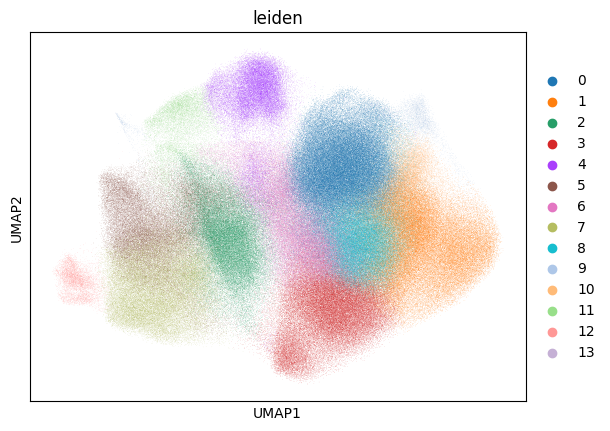

In [ ]:
# Compute neighborhood graph (if not already done)
sc.pp.neighbors(adata, use_rep="X_scVI") 

# Run Leiden clustering
sc.tl.leiden(adata, resolution=1.0, flavor="igraph")


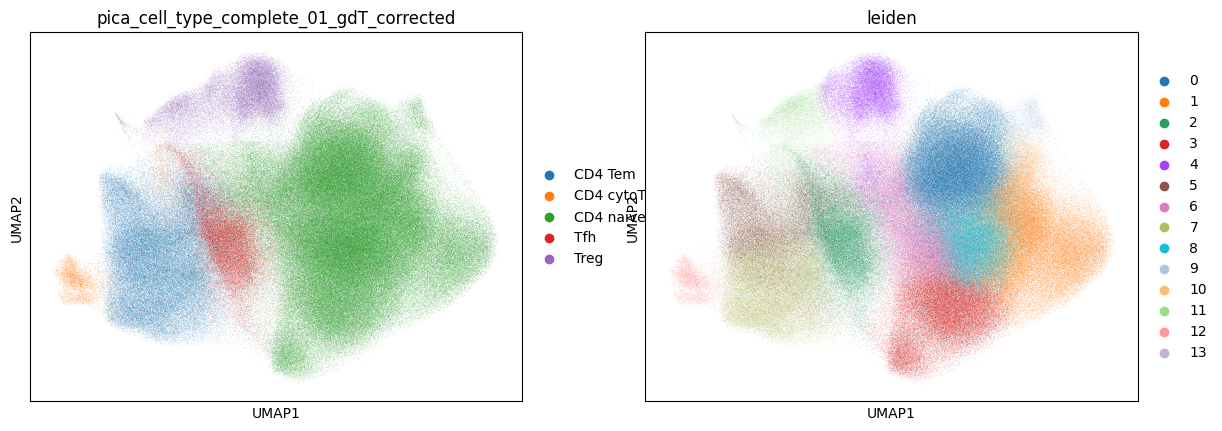

In [5]:
sc.pl.umap(adata, color=["pica_cell_type_complete_01_gdT_corrected", "leiden"])

In [4]:
adata

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [ ]:
adata.write_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/04_TCR/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi_tcr.h5ad", compression="gzip")

In [ ]:
adata = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/04_TCR/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi_tcr.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [3]:
# restrict Anndata
target_prefix = "20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1"

adata_cd4 = adata[
    adata.obs_names.astype(str).str.startswith(target_prefix)
].copy()

In [4]:
adata_cd4.obs["sequencing_batch"].head()

20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGAGGTATA    20250114_WGS_20241218_sc_PICA0071-PICA0097
20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGAGTTGGG    20250114_WGS_20241218_sc_PICA0071-PICA0097
20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGCCGATTA    20250114_WGS_20241218_sc_PICA0071-PICA0097
20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAGCAAGCGCGA    20250114_WGS_20241218_sc_PICA0071-PICA0097
20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAGCACGTTATA    20250114_WGS_20241218_sc_PICA0071-PICA0097
Name: sequencing_batch, dtype: category
Categories (1, object): ['20250114_WGS_20241218_sc_PICA0071-PICA0097']

In [5]:
adata_cd4.shape

(13985, 38606)

## Load VDJ object

In [6]:
vdj = ddl.read_10x_vdj(vdj_dir, filename_prefix="filtered")
vdj

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/core/_core.py:1995: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.


Lazy Dandelion object with n_obs = 28873 and n_contigs = 59212
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, sequence, rearrangement_status
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, locus_status, chain_status, rearrangement_status_

In [7]:
vdj.data.head().collect()
vdj.metadata.head().collect()

cell_id,clone_id,clone_id_rank,locus_VDJ,locus_VJ,v_call_VDJ,v_call_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,c_call_VDJ,c_call_VJ,junction_aa_VDJ,junction_aa_VJ,junction_VDJ,junction_VJ,umi_count_VDJ,umi_count_VJ,locus_VDJ_main,locus_VJ_main,v_call_VDJ_main,v_call_VJ_main,d_call_VDJ_main,j_call_VDJ_main,j_call_VJ_main,c_call_VDJ_main,c_call_VJ_main,junction_aa_VDJ_main,junction_aa_VJ_main,junction_VDJ_main,junction_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ
str,str,cat,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str
"""AAACCAAAGACAGCCT-1""","""sample0_clonotype26793""","""23612""","""TRB""","""TRA""","""TRBV13""","""TRAV21""",null,"""TRBJ1-4""","""TRAJ52""","""TRBC1""","""TRAC""","""CASSQRGINEKLFF""","""CAASGGGTSYGKLTF""","""TGTGCCAGCAGCCAAAGGGGAATCAATGAA…","""TGTGCTGCTTCGGGTGGTGGTACTAGCTAT…",26,9,"""TRB""","""TRA""","""TRBV13""","""TRAV21""",null,"""TRBJ1-4""","""TRAJ52""","""TRBC1""","""TRAC""","""CASSQRGINEKLFF""","""CAASGGGTSYGKLTF""","""TGTGCCAGCAGCCAAAGGGGAATCAATGAA…","""TGTGCTGCTTCGGGTGGTGGTACTAGCTAT…",26.0,9.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""AAACCAAAGAGGTATA-1""","""sample0_clonotype4234""","""1996""","""TRB""","""TRA""","""TRBV29-1""","""TRAV9-2""",null,"""TRBJ1-1""","""TRAJ9""","""TRBC1""","""TRAC""","""CSVRDRDEHTEAFF""","""CALTVNTGGFKTIF""","""TGCAGCGTTCGCGACCGGGACGAACACACT…","""TGTGCTCTGACCGTAAATACTGGAGGCTTC…",41,10,"""TRB""","""TRA""","""TRBV29-1""","""TRAV9-2""",null,"""TRBJ1-1""","""TRAJ9""","""TRBC1""","""TRAC""","""CSVRDRDEHTEAFF""","""CALTVNTGGFKTIF""","""TGCAGCGTTCGCGACCGGGACGAACACACT…","""TGTGCTCTGACCGTAAATACTGGAGGCTTC…",41.0,10.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""AAACCAAAGAGTTGGG-1""","""sample0_clonotype16701""","""5668""","""TRB""","""TRA""","""TRBV14""","""TRAV2""",null,"""TRBJ1-1""","""TRAJ42""","""TRBC1""","""TRAC""","""CASSWGGGNTEAFF""","""CAVAEGSQGNLIF""","""TGTGCCAGCAGTTGGGGAGGGGGGAACACT…","""TGTGCTGTGGCCGAAGGAAGCCAAGGAAAT…",15,7,"""TRB""","""TRA""","""TRBV14""","""TRAV2""",null,"""TRBJ1-1""","""TRAJ42""","""TRBC1""","""TRAC""","""CASSWGGGNTEAFF""","""CAVAEGSQGNLIF""","""TGTGCCAGCAGTTGGGGAGGGGGGAACACT…","""TGTGCTGTGGCCGAAGGAAGCCAAGGAAAT…",15.0,7.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""AAACCAAAGATCGTAT-1""","""sample0_clonotype21965""","""16577""","""TRB""","""TRA""","""TRBV6-5""","""TRAV12-2""",null,"""TRBJ2-1""","""TRAJ27""","""TRBC2""","""TRAC""","""CASSIEGQNDYNEQFF""","""CAVRGLWTNAGKSTF""","""TGTGCCAGCAGTATCGAAGGCCAGAACGAC…","""TGTGCCGTGCGGGGACTATGGACCAATGCA…",8,2,"""TRB""","""TRA""","""TRBV6-5""","""TRAV12-2""",null,"""TRBJ2-1""","""TRAJ27""","""TRBC2""","""TRAC""","""CASSIEGQNDYNEQFF""","""CAVRGLWTNAGKSTF""","""TGTGCCAGCAGTATCGAAGGCCAGAACGAC…","""TGTGCCGTGCGGGGACTATGGACCAATGCA…",8.0,2.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""
"""AAACCAAAGATTCAAC-1""","""sample0_clonotype15469""","""7034""","""TRB""","""TRA""","""TRBV28""","""TRAV22""",null,"""TRBJ1-2""","""TRAJ33""","""TRBC1""","""TRAC""","""CASSLSGVRSYGYTF""","""CAVNEYSNYQLIW""","""TGTGCCAGCAGTTTATCAGGGGTTAGGAGC…","""TGTGCTGTGAATGAGTATAGCAACTATCAG…",11,5,"""TRB""","""TRA""","""TRBV28""","""TRAV22""",null,"""TRBJ1-2""","""TRAJ33""","""TRBC1""","""TRAC""","""CASSLSGVRSYGYTF""","""CAVNEYSNYQLIW""","""TGTGCCAGCAGTTTATCAGGGGTTAGGAGC…","""TGTGCTGTGAATGAGTATAGCAACTATCAG…",11.0,5.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard"""


In [8]:
vdj.add_cell_prefix(f"{target_prefix}_")

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/core/_core.py:1995: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.


In [9]:
# clean cell_id to match
vdj.data = vdj.data.with_columns(
    vdj.data["cell_id"].str.replace(r"-1$", "").alias("cell_id")
)

In [10]:
vdj.data.select("cell_id").collect().to_pandas()["cell_id"].head(10).tolist()

['20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGACAGCCT',
 '20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGACAGCCT',
 '20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGAGGTATA',
 '20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGAGGTATA',
 '20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGAGTTGGG',
 '20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGAGTTGGG',
 '20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGATCGTAT',
 '20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGATCGTAT',
 '20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGATTCAAC',
 '20250114_WGS_20241218_sc_PICA0071-PICA0097_Pool_1_AAACCAAAGATTCAAC']

In [11]:
# Restrict VDJ metadata
# get RNA cell IDs
rna_ids = set(adata_cd4.obs_names.astype(str))

# subset VDJ
vdj = vdj[vdj.data["cell_id"].is_in(rna_ids)]

In [12]:
# check match
vdj_ids = set(
    vdj.data.select("cell_id").collect().to_pandas()["cell_id"].astype(str)
)

rna_ids = set(adata_cd4.obs_names.astype(str))

print("Matched:", len(vdj_ids & rna_ids))
print("Only in RNA:", len(rna_ids - vdj_ids))
print("Only in VDJ:", len(vdj_ids - rna_ids))

Matched: 13592
Only in RNA: 393
Only in VDJ: 0


In [13]:
# QC: Remove low quality contigs 
vdj_cd4, adata_cd4 = ddl.pp.check_contigs(
    vdj,
    adata=adata_cd4,
    library_type="tr-ab"
)

print(vdj_cd4)
print(adata_cd4)

Filtering contigs...
Marking ambiguous contigs...
Initializing DandelionPolars object...


/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/core/_core.py:1995: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.


Lazy Dandelion object with n_obs = 13592 and n_contigs = 26322
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, sequence, rearrangement_status, extra, ambiguous
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, productive_VDJ_main, productive_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main

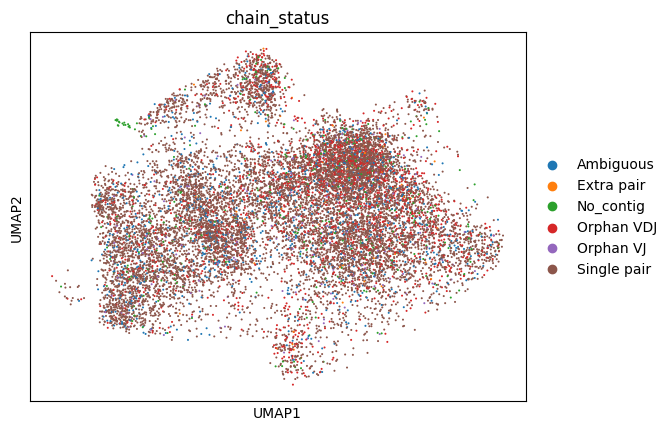

In [14]:
sc.pl.umap(adata_cd4, color=["chain_status"])

In [ ]:
"""
ddl.tl.find_clone(vdj_cd4)
vdj_cd4
"""

In [15]:
# Compute clone sizes
ddl.tl.clone_size(vdj_cd4)
vdj_cd4

Lazy Dandelion object with n_obs = 13592 and n_contigs = 26322
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, sequence, rearrangement_status, extra, ambiguous
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, productive_VDJ_main, productive_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main

In [16]:
# build clone network
ddl.tl.generate_network(vdj_cd4, key="junction_aa")
vdj_cd4

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/tools/_network.py:280: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.
/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/tools/_network.py:313: PerformanceWarning: checking membership of a LazyFrame using `in` requires resolving its schema, which is a potentially expensive operation. Use `key in LazyFrame.collect_schema()` to check membership without this warning.
100%|██████████| 13372/13372 [00:00<00:00, 2386648.22it/s]


Lazy Dandelion object with n_obs = 13592 and n_contigs = 26322
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, fwr1_aa, fwr1, cdr1_aa, cdr1, fwr2_aa, fwr2, cdr2_aa, cdr2, fwr3_aa, fwr3, junction_aa, junction, fwr4_aa, fwr4, consensus_count, umi_count, clone_id, raw_consensus_id_10x, exact_subclonotype_id_10x, sequence, rearrangement_status, extra, ambiguous
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, productive_VDJ, productive_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, productive_VDJ_main, productive_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main

In [17]:
vdj_cd4.data.head().collect()
vdj_cd4.metadata.head().collect()

cell_id,clone_id,clone_id_rank,locus_VDJ,locus_VJ,v_call_VDJ,v_call_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,c_call_VDJ,c_call_VJ,productive_VDJ,productive_VJ,junction_aa_VDJ,junction_aa_VJ,junction_VDJ,junction_VJ,umi_count_VDJ,umi_count_VJ,locus_VDJ_main,locus_VJ_main,v_call_VDJ_main,v_call_VJ_main,d_call_VDJ_main,j_call_VDJ_main,j_call_VJ_main,c_call_VDJ_main,c_call_VJ_main,productive_VDJ_main,productive_VJ_main,junction_aa_VDJ_main,junction_aa_VJ_main,junction_VDJ_main,junction_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ,clone_id_size,clone_id_size_prop,clone_id_size_category
str,str,cat,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,i64,f64,str
"""20250114_WGS_20241218_sc_PICA0…","""sample0_clonotype4234""","""6092""","""TRB""","""TRA""","""TRBV29-1""","""TRAV9-2""",null,"""TRBJ1-1""","""TRAJ9""","""TRBC1""","""TRAC""","""T""","""T""","""CSVRDRDEHTEAFF""","""CALTVNTGGFKTIF""","""TGCAGCGTTCGCGACCGGGACGAACACACT…","""TGTGCTCTGACCGTAAATACTGGAGGCTTC…",41,10,"""TRB""","""TRA""","""TRBV29-1""","""TRAV9-2""",null,"""TRBJ1-1""","""TRAJ9""","""TRBC1""","""TRAC""","""T""","""T""","""CSVRDRDEHTEAFF""","""CALTVNTGGFKTIF""","""TGCAGCGTTCGCGACCGGGACGAACACACT…","""TGTGCTCTGACCGTAAATACTGGAGGCTTC…",41.0,10.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard""",1,0.000074,"""Rare"""
"""20250114_WGS_20241218_sc_PICA0…","""sample0_clonotype16701""","""7193""","""TRB""","""TRA""","""TRBV14""","""TRAV2""",null,"""TRBJ1-1""","""TRAJ42""","""TRBC1""","""TRAC""","""T""","""T""","""CASSWGGGNTEAFF""","""CAVAEGSQGNLIF""","""TGTGCCAGCAGTTGGGGAGGGGGGAACACT…","""TGTGCTGTGGCCGAAGGAAGCCAAGGAAAT…",15,7,"""TRB""","""TRA""","""TRBV14""","""TRAV2""",null,"""TRBJ1-1""","""TRAJ42""","""TRBC1""","""TRAC""","""T""","""T""","""CASSWGGGNTEAFF""","""CAVAEGSQGNLIF""","""TGTGCCAGCAGTTGGGGAGGGGGGAACACT…","""TGTGCTGTGGCCGAAGGAAGCCAAGGAAAT…",15.0,7.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard""",1,0.000074,"""Rare"""
"""20250114_WGS_20241218_sc_PICA0…","""sample0_clonotype654""","""3274""","""TRB""","""TRA""","""TRBV2""","""TRAV21""",null,"""TRBJ2-7""","""TRAJ49""","""TRBC2""","""TRAC""","""T""","""T""","""CASSAMASGRSYEQYF""","""CAVRRSNQFYF""","""TGTGCCAGCAGCGCCATGGCTAGCGGGAGG…","""TGTGCTGTGAGGCGAAGTAACCAGTTCTAT…",16,13,"""TRB""","""TRA""","""TRBV2""","""TRAV21""",null,"""TRBJ2-7""","""TRAJ49""","""TRBC2""","""TRAC""","""T""","""T""","""CASSAMASGRSYEQYF""","""CAVRRSNQFYF""","""TGTGCCAGCAGCGCCATGGCTAGCGGGAGG…","""TGTGCTGTGAGGCGAAGTAACCAGTTCTAT…",16.0,13.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard""",1,0.000074,"""Rare"""
"""20250114_WGS_20241218_sc_PICA0…","""sample0_clonotype6435""","""11719""","""TRB""","""TRA""","""TRBV5-4""","""TRAV4""",null,"""TRBJ1-2""","""TRAJ32""","""TRBC1""","""TRAC""","""T""","""T""","""CASSPGQYYGYTF""","""CLVGDYGGATNKLIF""","""TGTGCCAGCAGCCCAGGACAGTACTATGGC…","""TGCCTCGTGGGTGACTATGGTGGTGCTACA…",11,5,"""TRB""","""TRA""","""TRBV5-4""","""TRAV4""",null,"""TRBJ1-2""","""TRAJ32""","""TRBC1""","""TRAC""","""T""","""T""","""CASSPGQYYGYTF""","""CLVGDYGGATNKLIF""","""TGTGCCAGCAGCCCAGGACAGTACTATGGC…","""TGCCTCGTGGGTGACTATGGTGGTGCTACA…",11.0,5.0,"""TRB + TRA""","""Single pair""","""Standard""","""Standard""",1,0.000074,"""Rare"""
"""20250114_WGS_20241218_sc_PICA0…","""sample0_clonotype19596""","""9955""","""TRB""",null,"""TRBV11-3""",null,null,"""TRBJ2-1""",null,"""TRBC2""",null,"""T""",null,"""CASSYAGLRGSEQFF""",null,"""TGTGCCAGCAGCTATGCCGGACTCCGAGGA…",null,10,0,"""TRB""",null,"""TRBV11-3""",null,null,"""TRBJ2-1""",null,"""TRBC2""",null,"""T""",null,"""CASSYAGLRGSEQFF""",null,"""TGTGCCAGCAGCTATGCCGGACTCCGAGGA…",null,10.0,null,"""Orphan TRB""","""Orphan VDJ""","""Standard""",null,1,0.000074,"""Rare"""


### Transfer VDJ information into Scanpy object

In [18]:
ddl.tl.transfer(adata_cd4, vdj_cd4)
print([c for c in adata_cd4.obs.columns if "clone" in c.lower() or "contig" in c.lower()])

['has_contig', 'clone_id', 'clone_id_rank', 'clone_id_size', 'clone_id_size_prop', 'clone_id_size_category']


In [19]:
adata_cd4

AnnData object with n_obs × n_vars = 13985 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in y

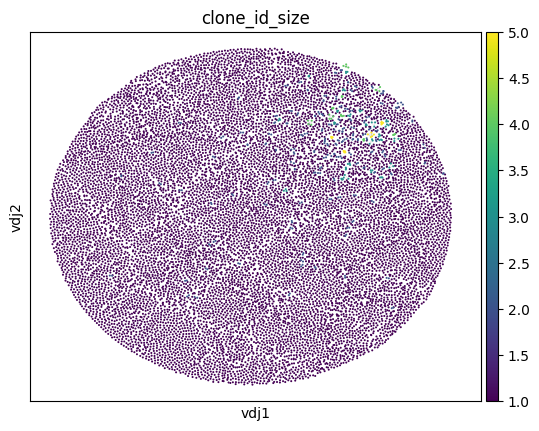

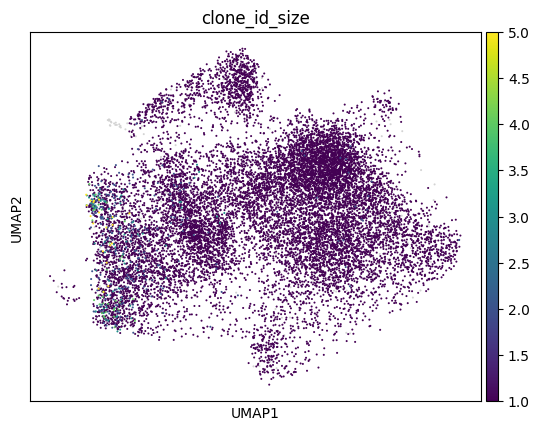

In [20]:
ddl.pl.clone_network(adata_cd4, color="clone_id_size")
sc.pl.umap(adata_cd4, color="clone_id_size")

## Clone annotation

In [21]:
adata_cd4.obs["expanded_clone"] = adata_cd4.obs["clone_id_size"].fillna(0) > 1

# ordered categorical for cleaner legends
clone_order = ["Small", "Medium", "Large", "Hyperexpanded"]
if "clone_id_size_category" in adata_cd4.obs.columns:
    adata_cd4.obs["clone_id_size_category"] = pd.Categorical(
        adata_cd4.obs["clone_id_size_category"],
        categories=clone_order,
        ordered=True
    )

In [22]:
celltype_col = "pica_cell_type_complete_01_gdT_corrected"

# keep only cells with contigs for TCR-based summaries
if "has_contig" in adata_cd4.obs.columns:
    adata_tcr = adata_cd4[adata_cd4.obs["has_contig"].astype(str) == "True"].copy()
else:
    adata_tcr = adata_cd4.copy()

In [23]:
age_bins = [0, 3, 6, 10, 14, 18]
age_labels = ["0–3", "4–6", "7–10", "11–14", "15–18"]

adata_tcr.obs["Age_group"] = pd.cut(
        adata_tcr.obs["Age_years"],
        bins= age_bins,
        labels= age_labels,
        right=False
    )

adata_tcr.obs["Age_group"] = adata_tcr.obs["Age_group"].cat.set_categories(age_labels)

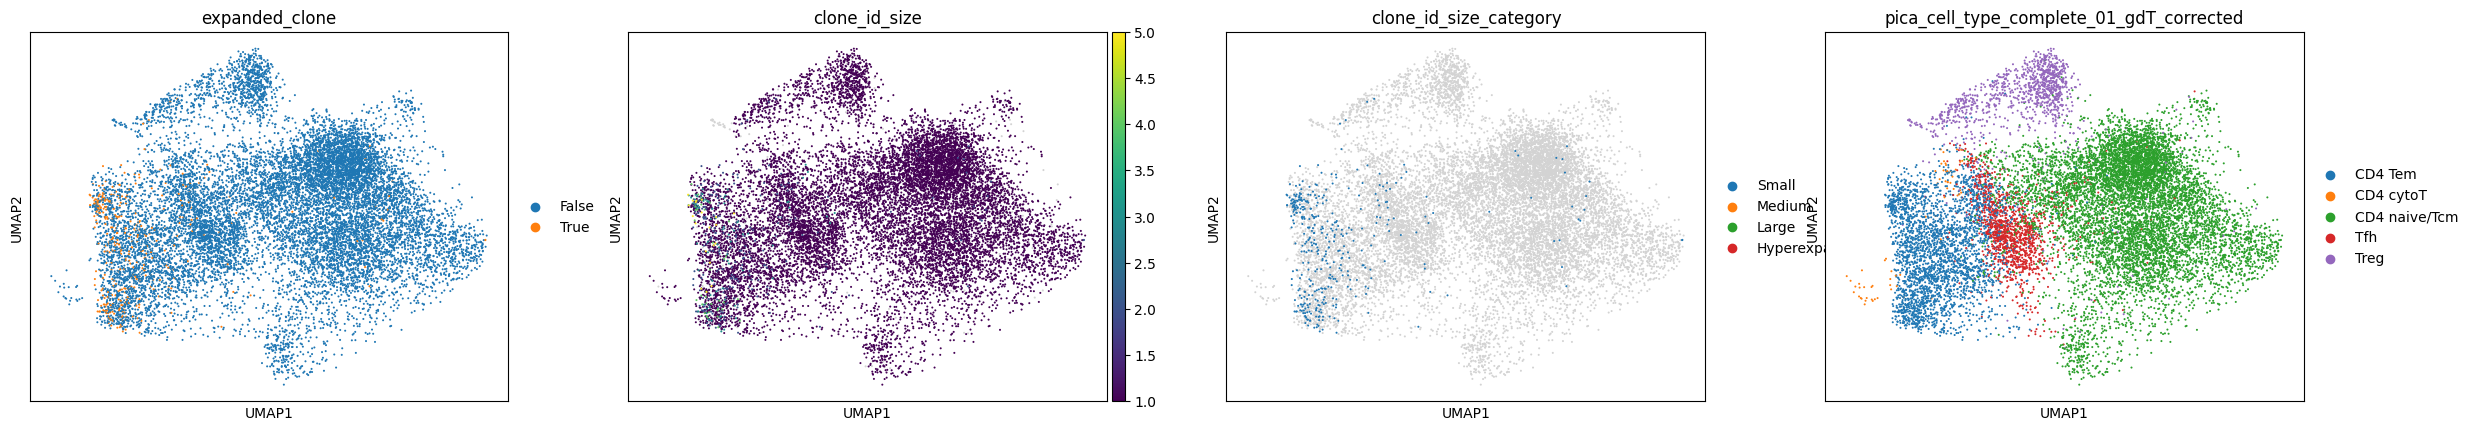

In [24]:
sc.pl.umap(
    adata_cd4,
    color=[
        "expanded_clone",
        "clone_id_size",
        "clone_id_size_category",
        celltype_col,
    ],
    na_in_legend=False,
)

## visualization

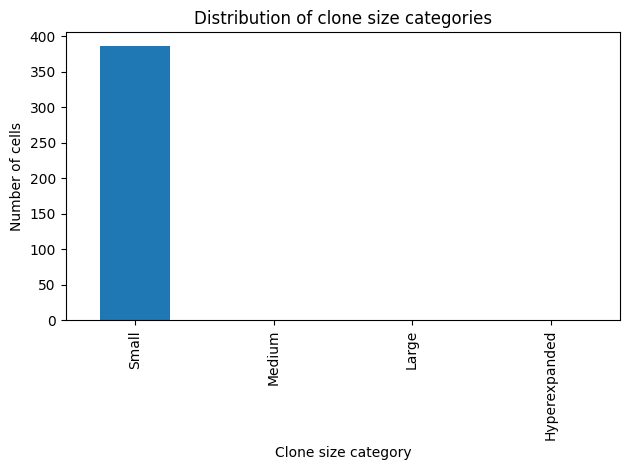

In [25]:
# Clone size distribution
clone_counts = (
    adata_tcr.obs["clone_id_size_category"]
    .value_counts(dropna=False)
    .reindex(clone_order)
)

clone_counts.plot(kind="bar")
plt.ylabel("Number of cells")
plt.xlabel("Clone size category")
plt.title("Distribution of clone size categories")
plt.tight_layout()
plt.show()


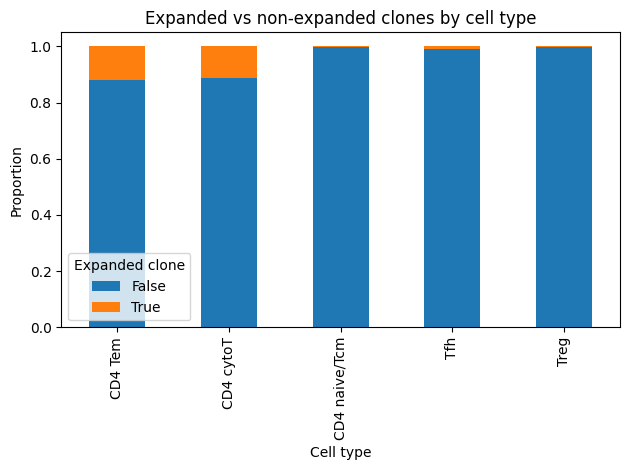

In [26]:
# Expanded clones by cell type
expanded_by_celltype = pd.crosstab(
    adata_tcr.obs[celltype_col],
    adata_tcr.obs["expanded_clone"],
    normalize="index"
)

expanded_by_celltype.plot(kind="bar", stacked=True)
plt.ylabel("Proportion")
plt.xlabel("Cell type")
plt.title("Expanded vs non-expanded clones by cell type")
plt.legend(title="Expanded clone")
plt.tight_layout()
plt.show()

### Dandelion plots

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


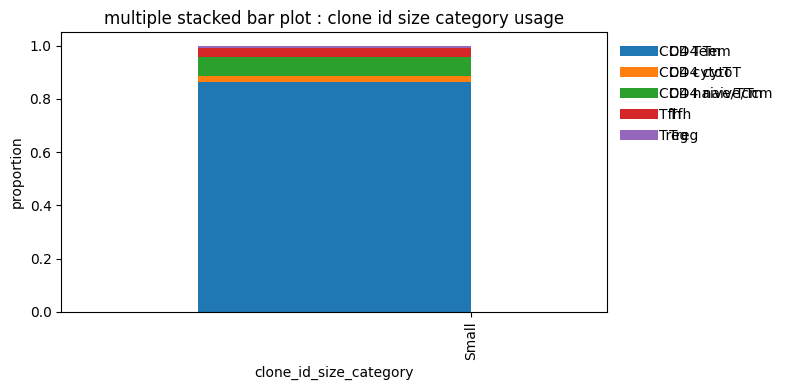

In [27]:
ddl.pl.stackedbarplot(
    adata_tcr,
    group_by=celltype_col,
    color="clone_id_size_category",
    normalize=True,
    figsize=(8, 4),
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



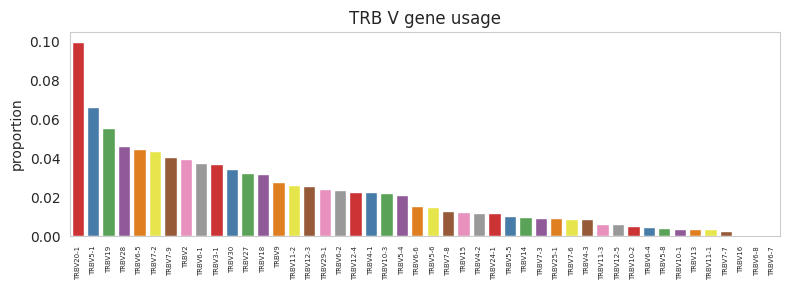

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



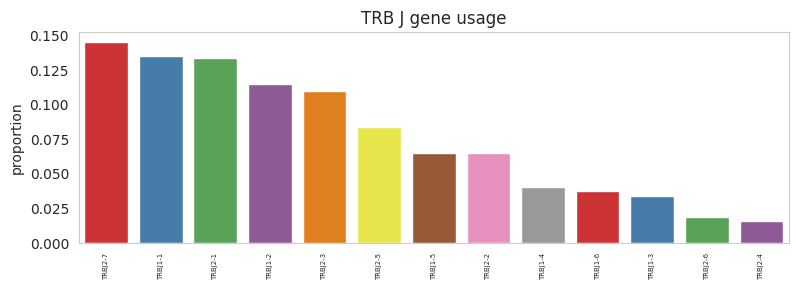

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



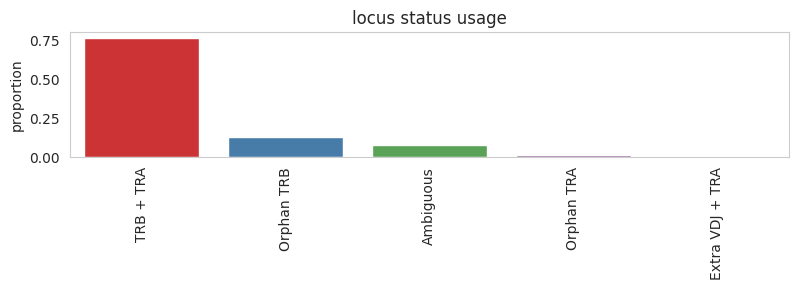

In [28]:
# TRB V gene usage / J gene usage barplots

ddl.pl.barplot(
    vdj_cd4,
    color="v_call_VDJ_main",
    xtick_fontsize=5,
)
plt.title("TRB V gene usage")
plt.tight_layout()
plt.show()


ddl.pl.barplot(
    vdj_cd4,
    color="j_call_VDJ_main",
    xtick_fontsize=5,
)
plt.title("TRB J gene usage")
plt.tight_layout()
plt.show()


ddl.pl.barplot(
    vdj_cd4,
    color="locus_status",
)
plt.tight_layout()
plt.show()

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



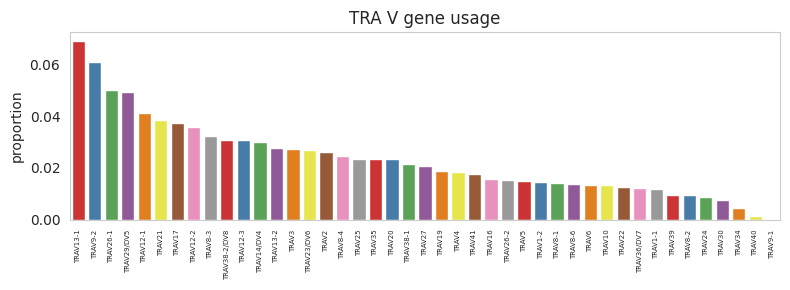

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



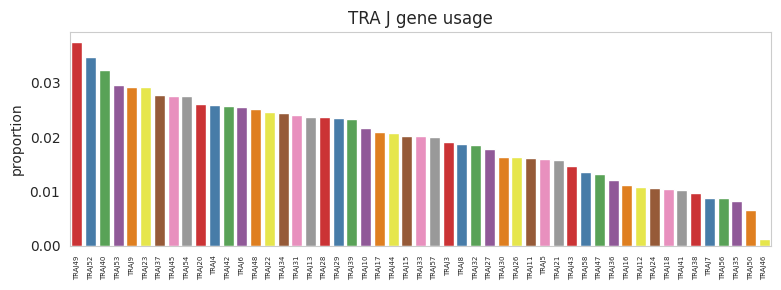

In [29]:
# TRA V gene usage / J gene usage barplots

ddl.pl.barplot(
    vdj_cd4,
    color="v_call_VJ_main",
    xtick_fontsize=5,
)
plt.title("TRA V gene usage")
plt.tight_layout()
plt.show()


ddl.pl.barplot(
    vdj_cd4,
    color="j_call_VJ_main",
    xtick_fontsize=5,
)
plt.title("TRA J gene usage")
plt.tight_layout()
plt.show()

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



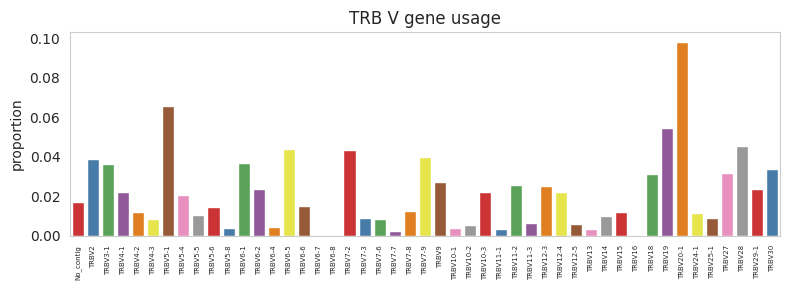

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



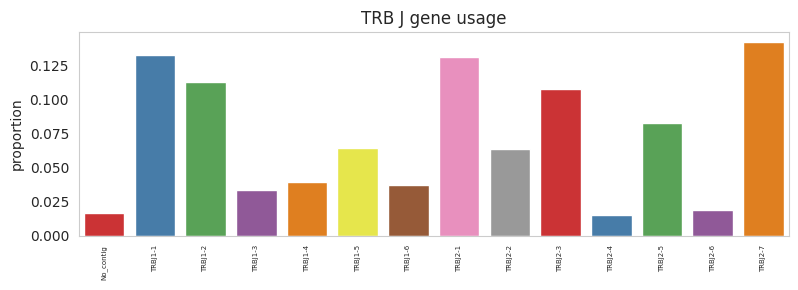

In [ ]:
# with contigs
ddl.pl.barplot(
    adata_tcr,
    color="v_call_VDJ_main",
    xtick_fontsize=5,
)
plt.title("TRB V gene usage")
plt.tight_layout()
plt.show()


ddl.pl.barplot(
    adata_tcr,
    color="j_call_VDJ_main",
    xtick_fontsize=5,
)
plt.title("TRB J gene usage")
plt.tight_layout()
plt.show()

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



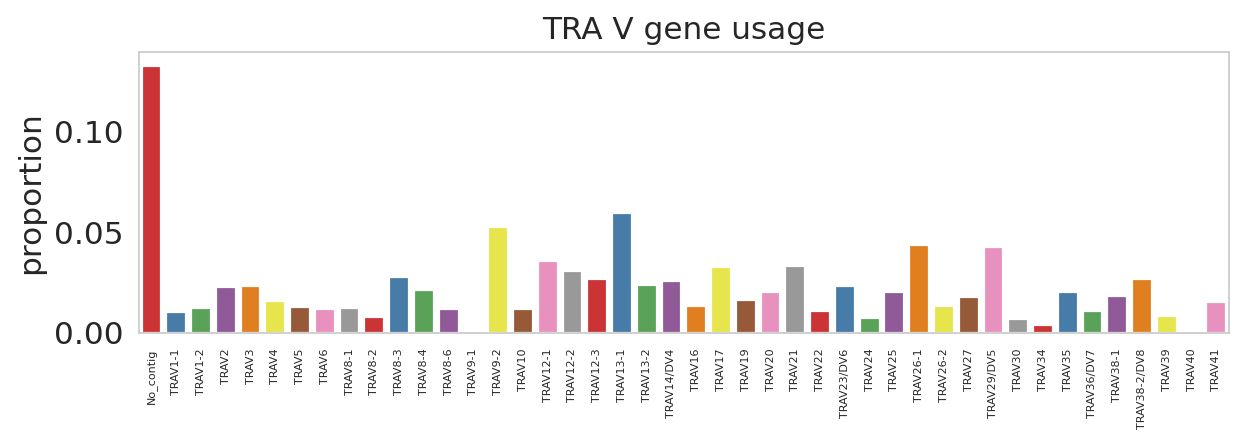

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



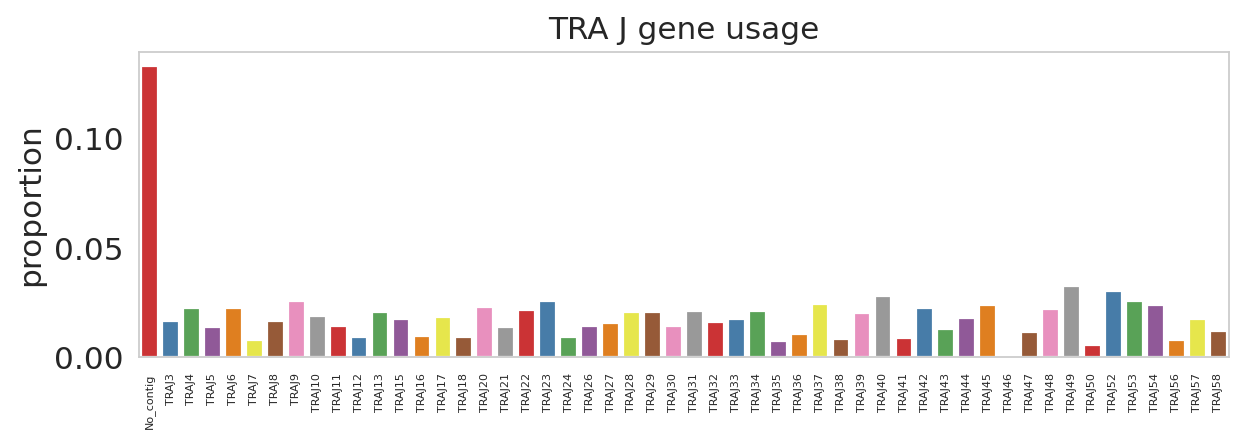

In [38]:
ddl.pl.barplot(
    adata_tcr,
    color="v_call_VJ_main",
    xtick_fontsize=5,
)
plt.title("TRA V gene usage")
plt.tight_layout()
plt.show()


ddl.pl.barplot(
    adata_tcr,
    color="j_call_VJ_main",
    xtick_fontsize=5,
)
plt.title("TRA J gene usage")
plt.tight_layout()
plt.show()

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


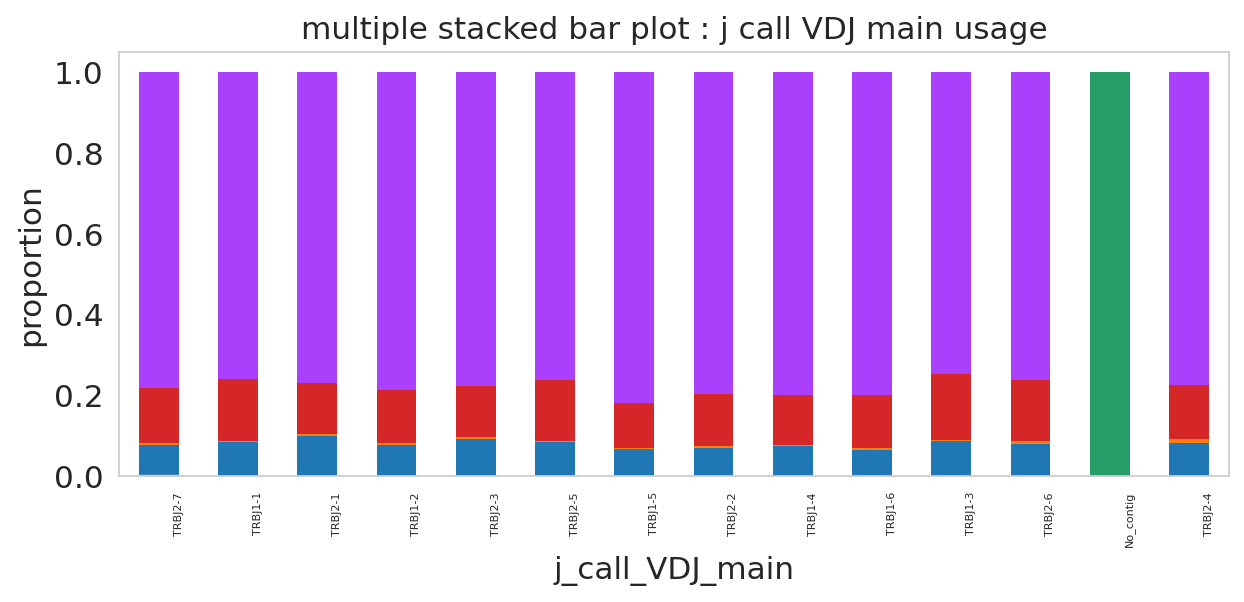

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


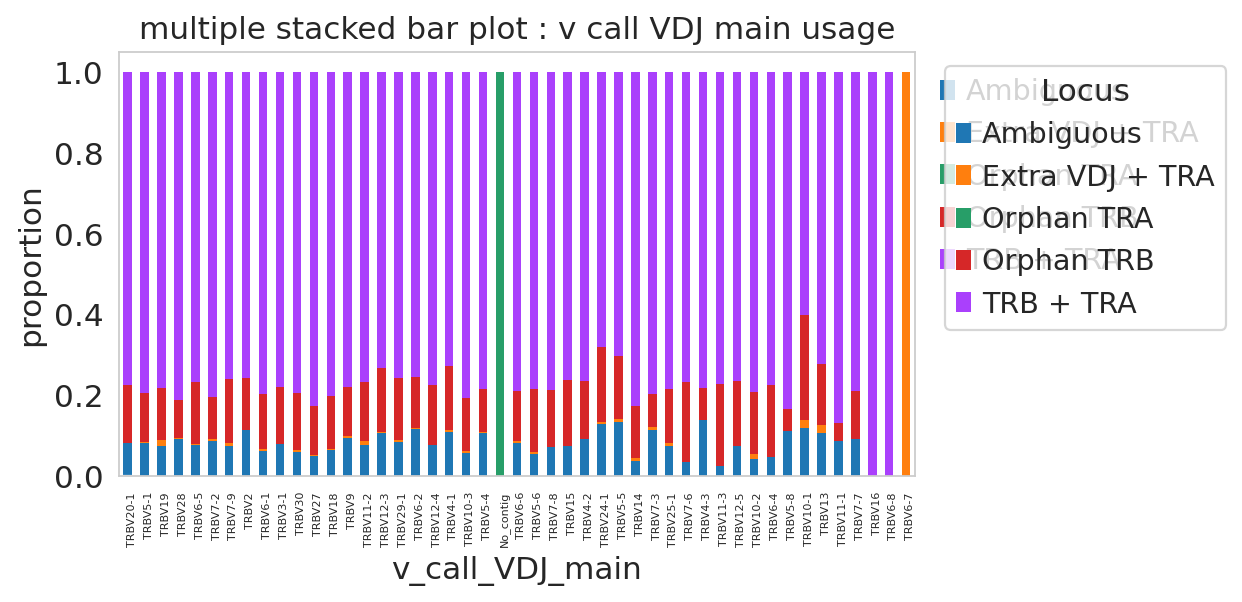

In [39]:
# Stacked barplots for V/J usage split by locus
ddl.pl.stackedbarplot(
    adata_tcr,
    color="j_call_VDJ_main",
    group_by="locus_status",
    normalize=True,
    xtick_fontsize=5,
    figsize=(8, 4),
)
plt.tight_layout()
plt.show()

ddl.pl.stackedbarplot(
    adata_tcr,
    color="v_call_VDJ_main",
    group_by="locus_status",
    normalize=True,
    xtick_fontsize=5,
    figsize=(8, 4),
)
plt.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


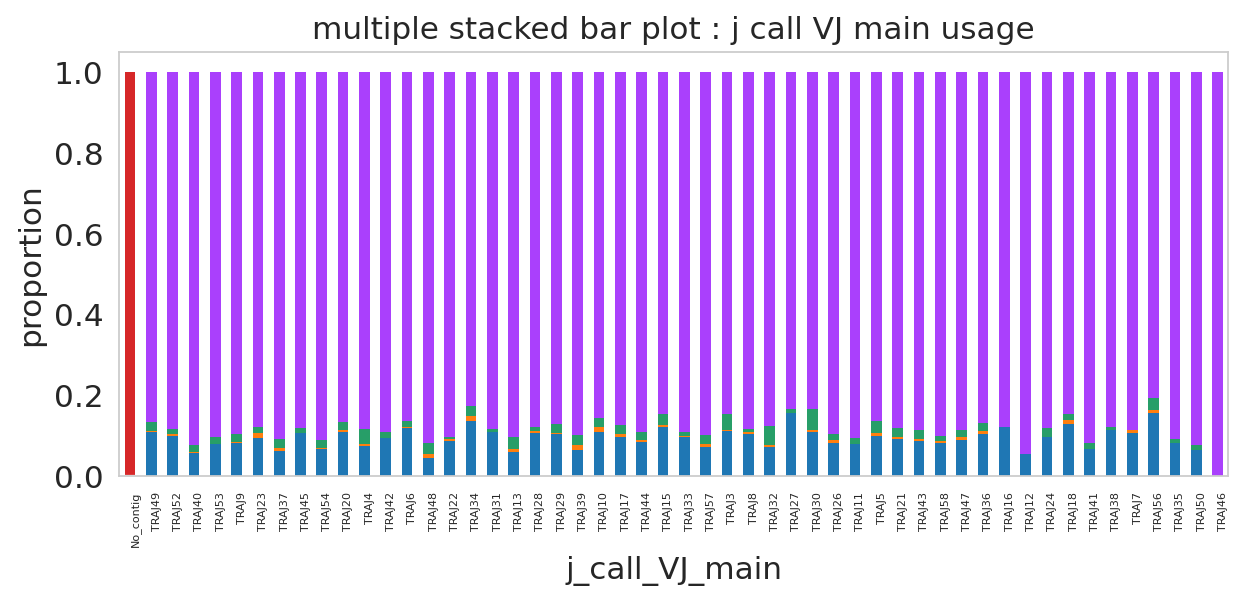

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


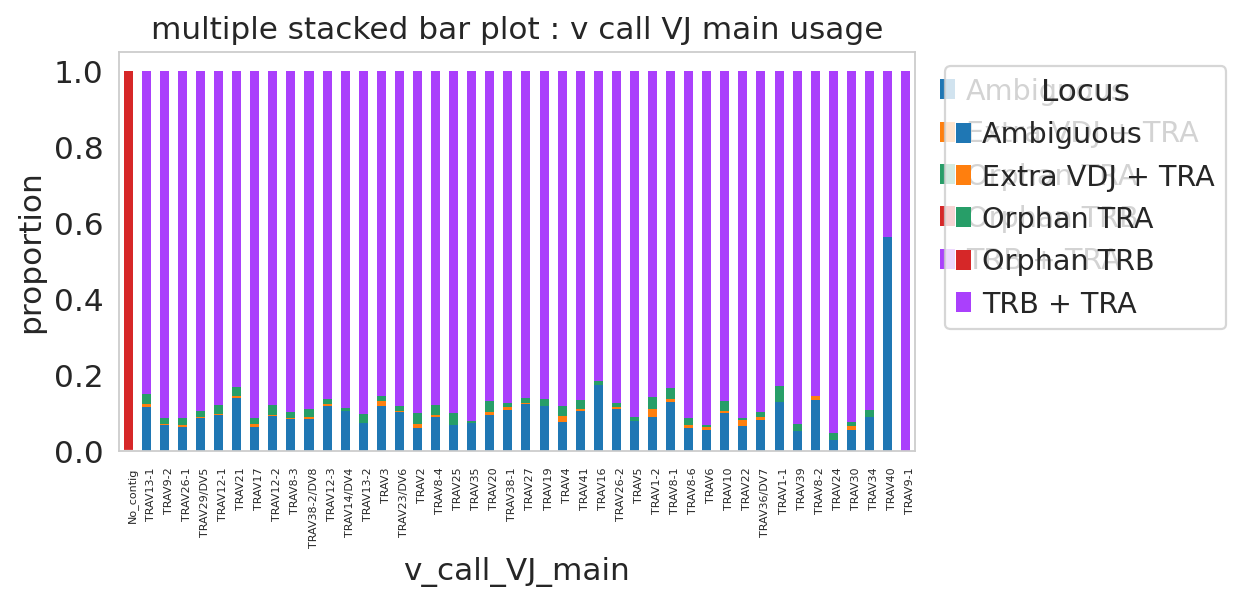

In [40]:
# Stacked barplots for V/J usage split by locus
ddl.pl.stackedbarplot(
    adata_tcr,
    color="j_call_VJ_main",
    group_by="locus_status",
    normalize=True,
    xtick_fontsize=5,
    figsize=(8, 4),
)
plt.tight_layout()
plt.show()

ddl.pl.stackedbarplot(
    adata_tcr,
    color="v_call_VJ_main",
    group_by="locus_status",
    normalize=True,
    xtick_fontsize=5,
    figsize=(8, 4),
)

plt.legend(title="Locus", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


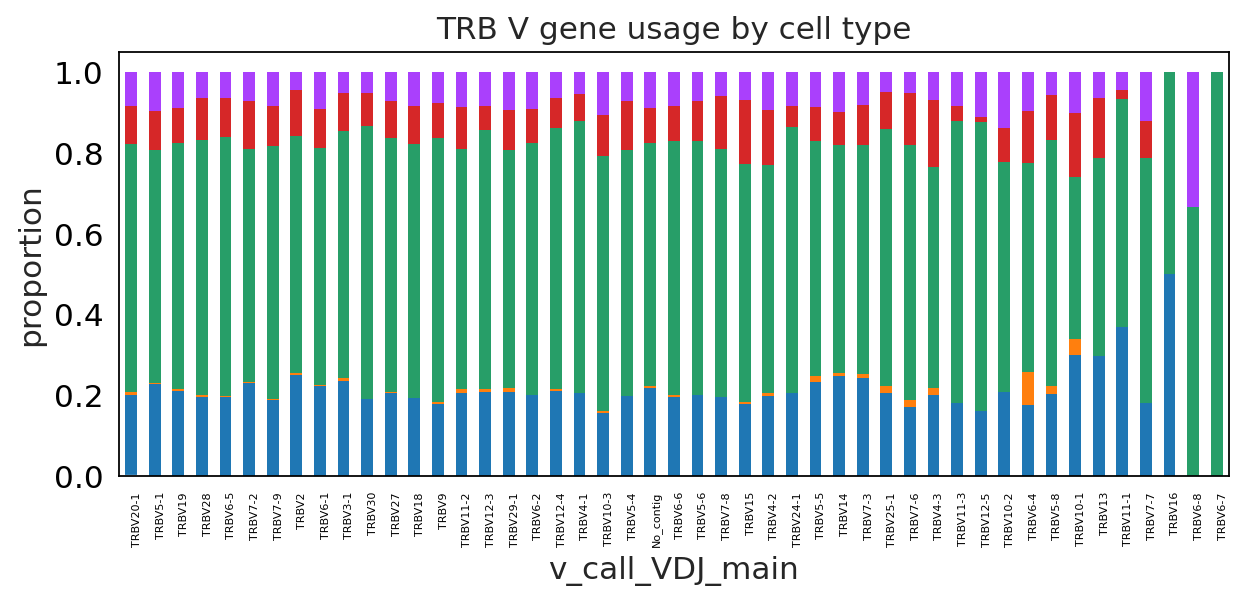

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


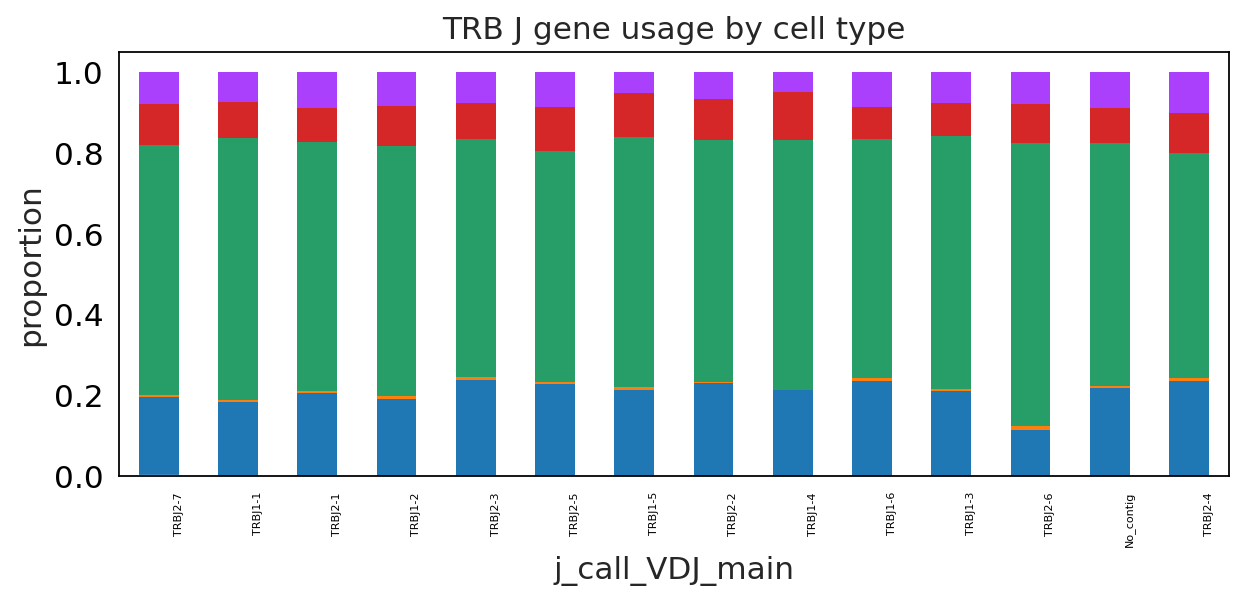

In [37]:
# by cell type
ddl.pl.stackedbarplot(
    adata_tcr,
    color="v_call_VDJ_main",
    group_by=celltype_col,
    normalize=True,
    xtick_fontsize=5,
    figsize=(8, 4),
)
plt.title("TRB V gene usage by cell type")
plt.tight_layout()
plt.show()

ddl.pl.stackedbarplot(
    adata_tcr,
    color="j_call_VDJ_main",
    group_by=celltype_col,
    normalize=True,
    xtick_fontsize=5,
    figsize=(8, 4),
)
plt.title("TRB J gene usage by cell type")
plt.tight_layout()
plt.show()

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


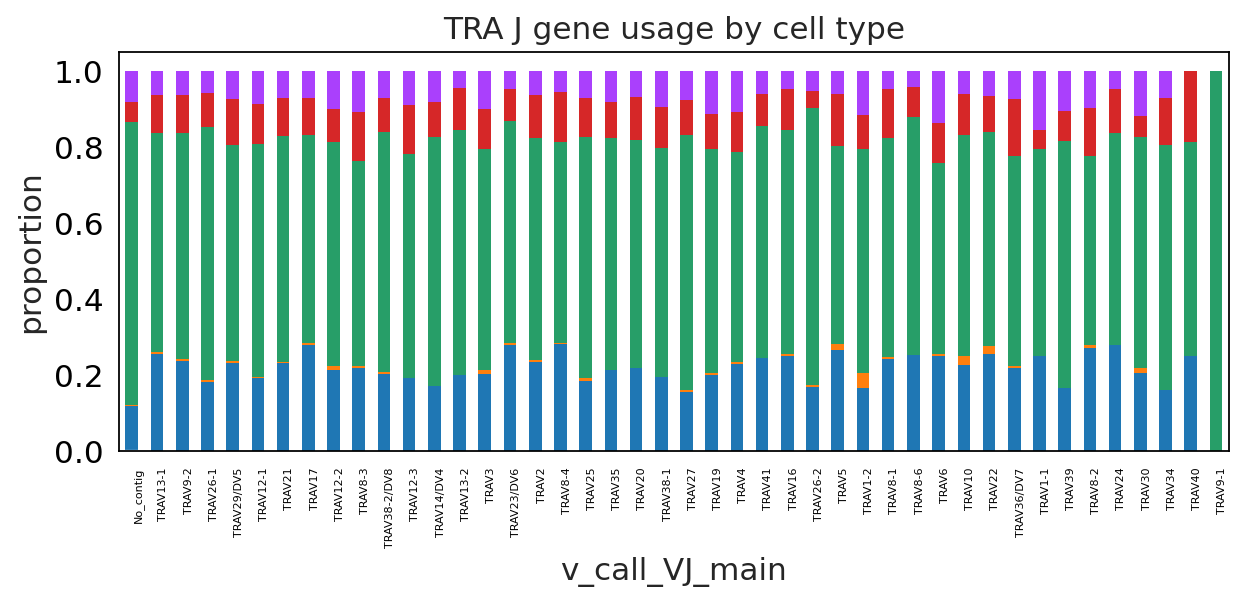

/scratch/user/s4575250/BIOX7014_Thesis/dandelion/src/dandelion/polars/plotting/_plotting.py:257: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


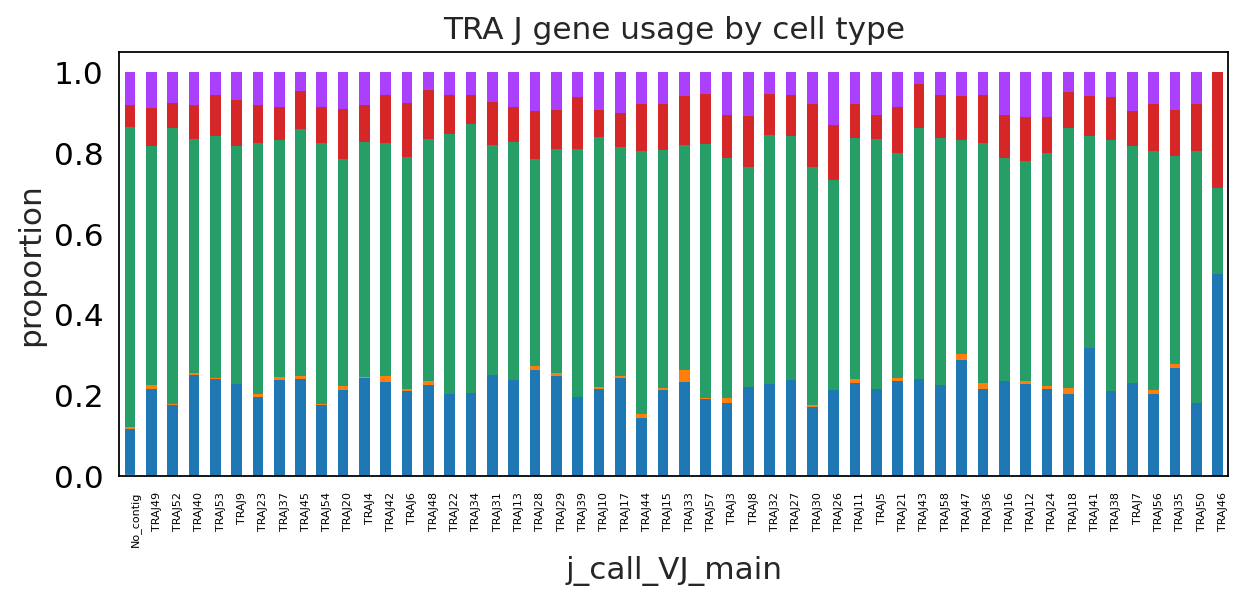

In [ ]:
# cell type
ddl.pl.stackedbarplot(
    adata_tcr,
    color="v_call_VJ_main",
    group_by=celltype_col,
    normalize=True,
    xtick_fontsize=5,
    figsize=(8, 4),
)
plt.title("TRA J gene usage by cell type")
plt.tight_layout()
plt.show()
    

ddl.pl.stackedbarplot(
    adata_tcr,
    color="j_call_VJ_main",
    group_by=celltype_col,
    normalize=True,
    xtick_fontsize=5,
    figsize=(8, 4),
)
plt.title("TRA J gene usage by cell type")
plt.tight_layout()
plt.show()

### Clone network views

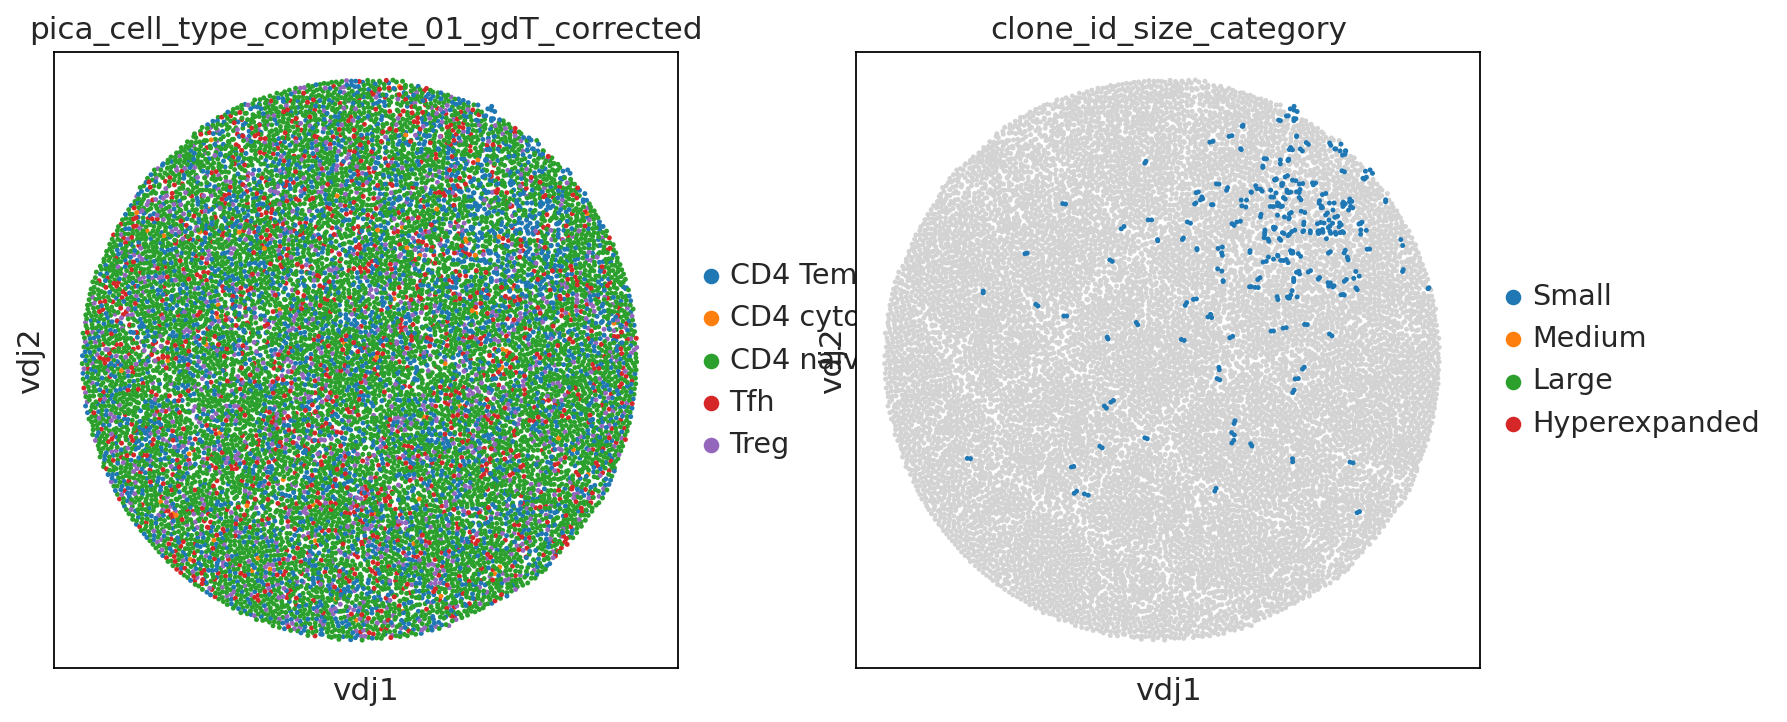

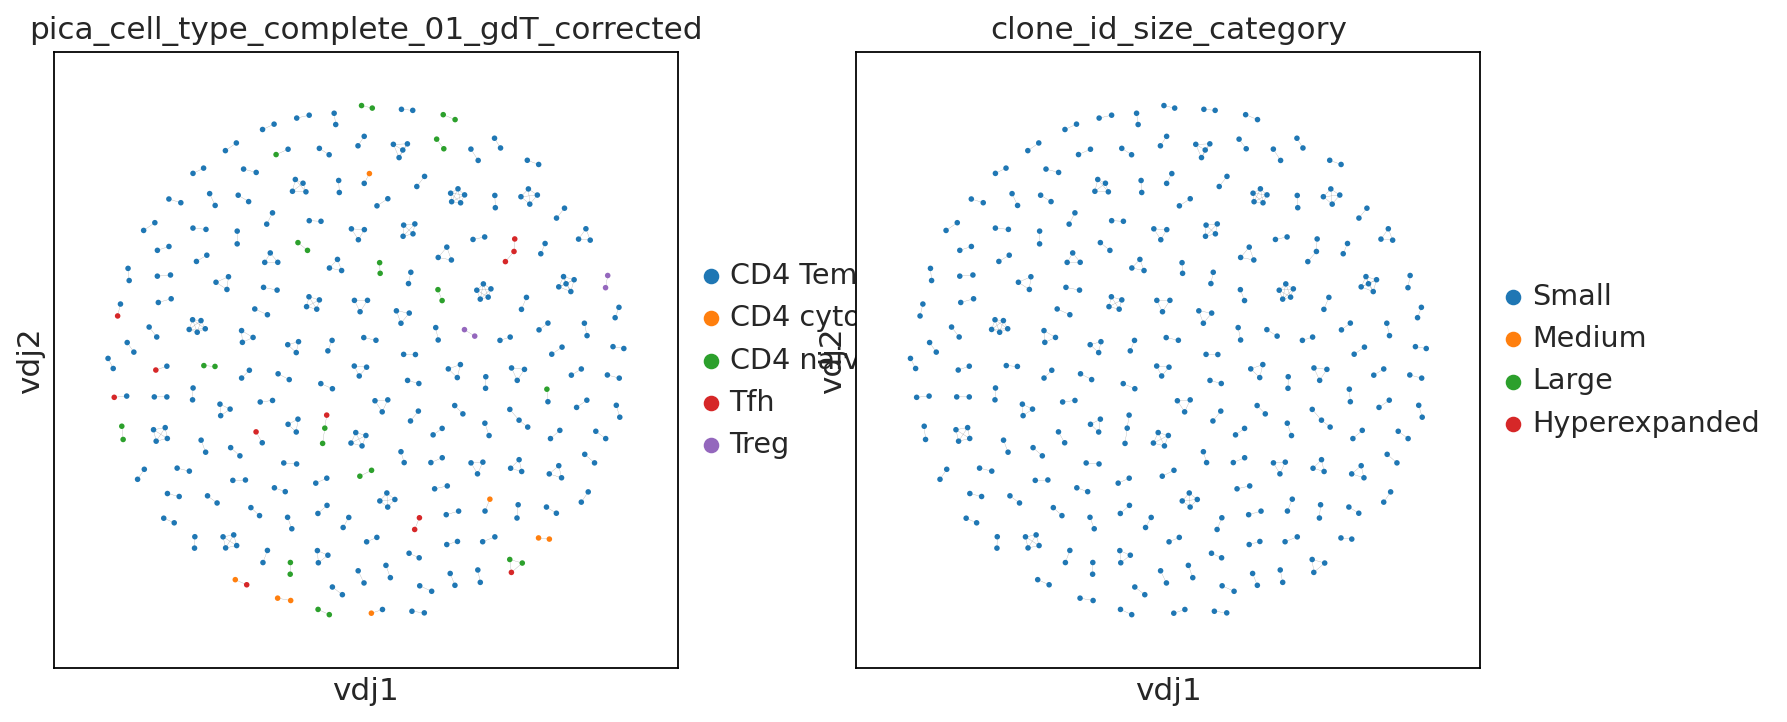

In [33]:
sc.set_figure_params(figsize=[5, 5])

# all clonotypes
ddl.tl.clone_view(adata_cd4, mode="all")
ddl.pl.clone_network(
    adata_cd4,
    color=[celltype_col, "clone_id_size_category"],
    ncols=2,
    size=20,
    na_in_legend=False,
)

plt.show()

# expanded clonotypes
ddl.tl.clone_view(adata_cd4, mode="expanded")
ddl.pl.clone_network(
    adata_cd4,
    color=[celltype_col, "clone_id_size_category"],
    ncols=2,
    size=25,
    na_in_legend=False,
)
plt.show()

### Clonal overlap between cell types

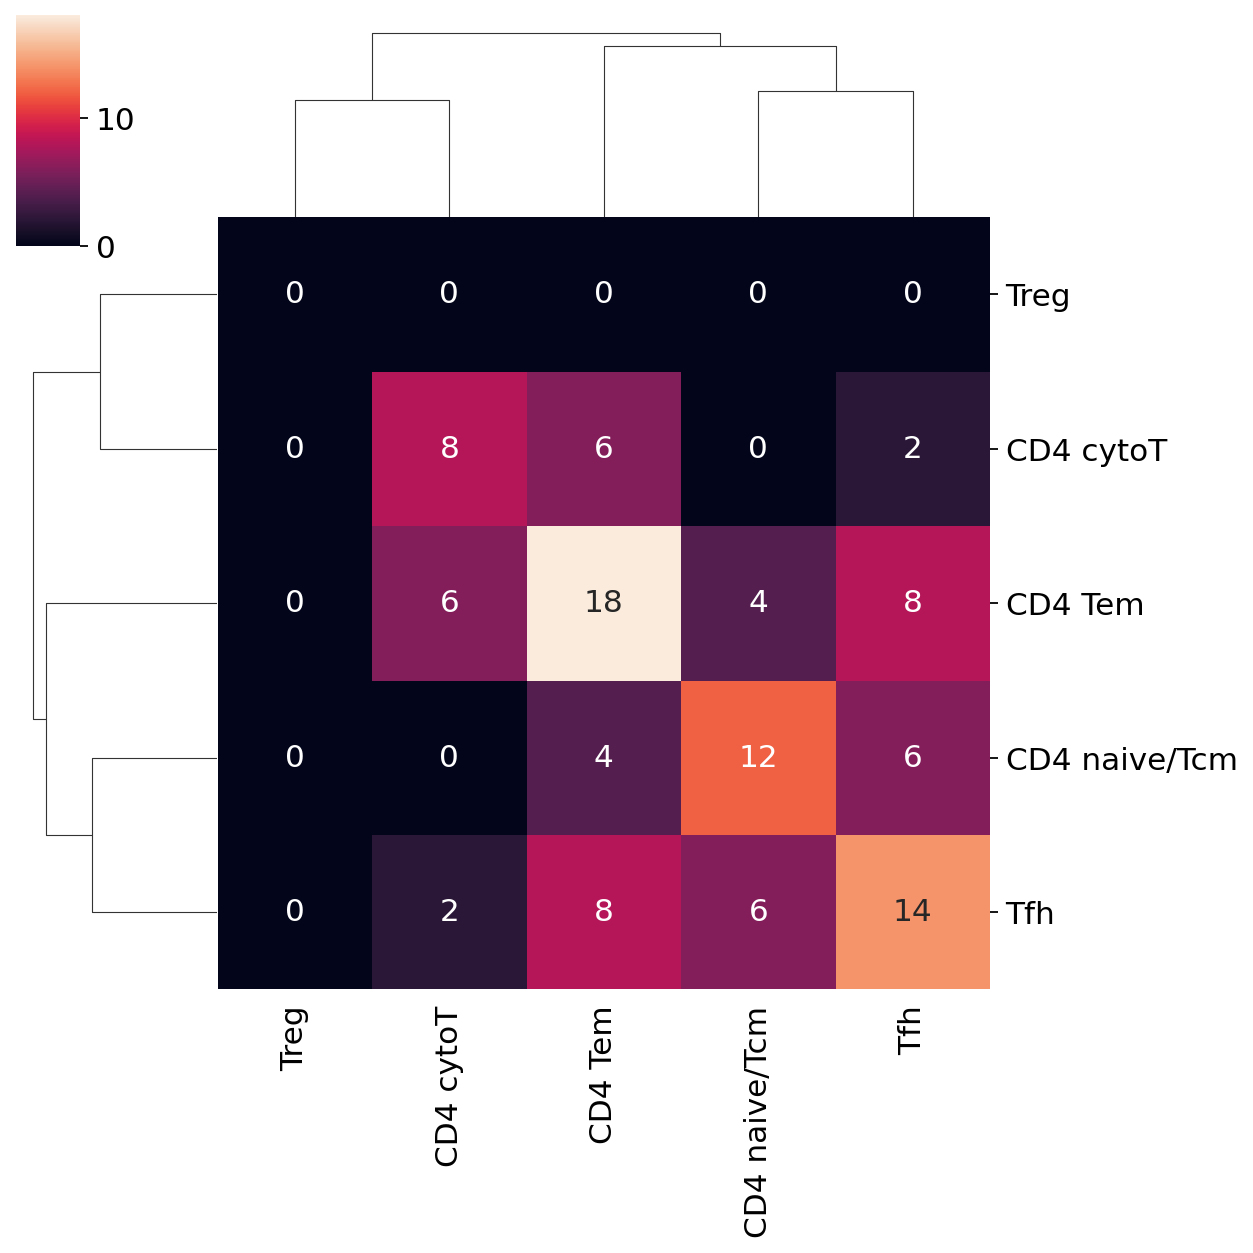

In [34]:
ddl.tl.clone_overlap(
        adata_tcr,
        group_by=celltype_col,
        weighted_overlap=True
    )
ddl.pl.clone_overlap(
    adata_tcr,
    group_by=celltype_col,
    weighted_overlap=True,
    as_heatmap=True,
    figsize=(8, 8),
    annot=True,
    fmt="g",
)
plt.show()


### Spectratype (TCR CDR3 length)

In [174]:
if "junction_aa_VDJ_main" in adata_tcr.obs.columns:
    adata_tcr.obs["junction_aa_VDJ_len"] = (
        adata_tcr.obs["junction_aa_VDJ_main"]
        .fillna("")
        .astype(str)
        .str.len()
        .replace(0, pd.NA)
    )

if "junction_aa_VJ_main" in adata_tcr.obs.columns:
    adata_tcr.obs["junction_aa_VJ_len"] = (
        adata_tcr.obs["junction_aa_VJ_main"]
        .fillna("")
        .astype(str)
        .str.len()
        .replace(0, pd.NA)
    )

# TRB spectratype
if {"junction_aa_VDJ_len", "v_call_VDJ_main"}.issubset(adata_tcr.obs.columns):
    trb_spec = adata_tcr[adata_tcr.obs["junction_aa_VDJ_len"].notna()].copy()

    if trb_spec.n_obs > 0:
        ddl.pl.spectratype(
            trb_spec,
            color="junction_aa_VDJ_len",
            group_by="v_call_VDJ_main",
            locus="TRB",
        )
        plt.title("TRB CDR3 length distribution")
        plt.tight_layout()
        plt.show()

# TRA spectratype
if {"junction_aa_VJ_len", "v_call_VJ_main"}.issubset(adata_tcr.obs.columns):
    tra_spec = adata_tcr[adata_tcr.obs["junction_aa_VJ_len"].notna()].copy()

    if tra_spec.n_obs > 0:
        ddl.pl.spectratype(
            tra_spec,
            color="junction_aa_VJ_len",
            group_by="v_call_VJ_main",
            locus="TRA",
        )
        plt.title("TRA CDR3 length distribution")
        plt.tight_layout()
        plt.show()

TypeError: Cannot setitem on a Categorical with a new category (), set the categories first

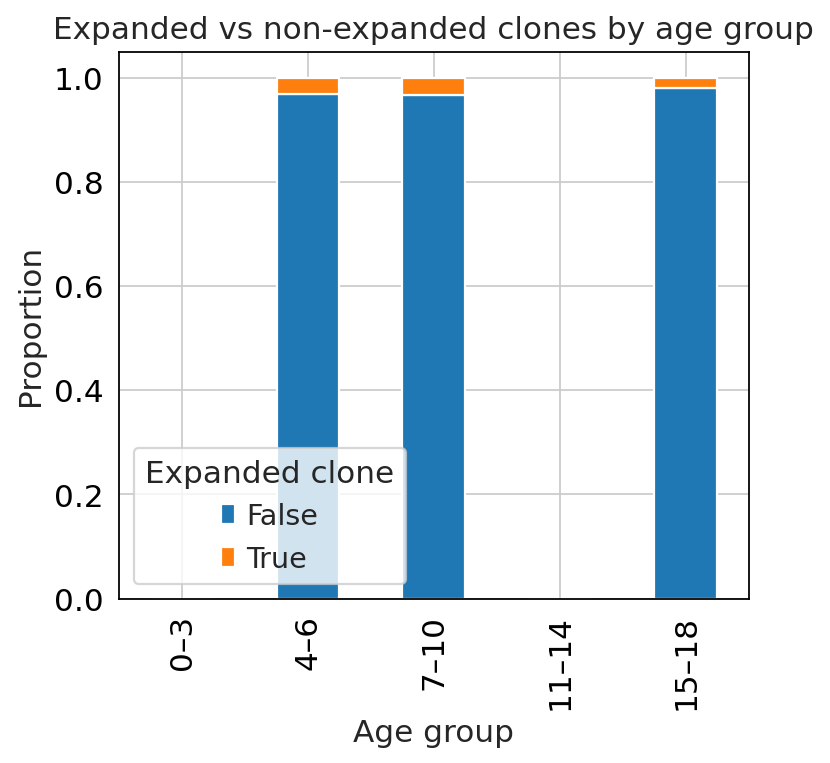

In [123]:
# Age_group plot
expanded_by_agegroup = pd.crosstab(
    adata_tcr.obs["Age_group"],
    adata_tcr.obs["expanded_clone"],
    normalize="index"
).reindex(age_labels) 

expanded_by_agegroup.plot(kind="bar", stacked=True)
plt.ylabel("Proportion")
plt.xlabel("Age group")
plt.title("Expanded vs non-expanded clones by age group")
plt.legend(title="Expanded clone")
plt.tight_layout()
plt.show()

In [3]:
donor_summary = (
    adata_tcr.obs.groupby("pica_id")
    .agg(
        n_tcr_cells=("expanded_clone", "size"),
        n_expanded=("expanded_clone", "sum"),
        prop_expanded=("expanded_clone", "mean"),
        median_clone_size=("clone_id_size", "median"),
        mean_clone_size=("clone_id_size", "mean"),
    )
    .sort_index()
)

donor_meta = (
    adata_tcr.obs
    .groupby("pica_id")[["Age_years", "Sex"]]
    .first()
)
donor_summary = donor_summary.join(donor_meta)

print(donor_summary)

          n_tcr_cells  n_expanded  prop_expanded  median_clone_size  \
pica_id                                                               
PICA0071         3798         122       0.032122                1.0   
PICA0072         5545         172       0.031019                1.0   
PICA0073         4642          92       0.019819                1.0   

          mean_clone_size  Age_years   Sex  
pica_id                                     
PICA0071         1.054360       6.99  Male  
PICA0072         1.050272       4.36  Male  
PICA0073         1.026403      14.97  Male  


/scratch/temp/23581889/ipykernel_3069228/2683017710.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/23581889/ipykernel_3069228/2683017710.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


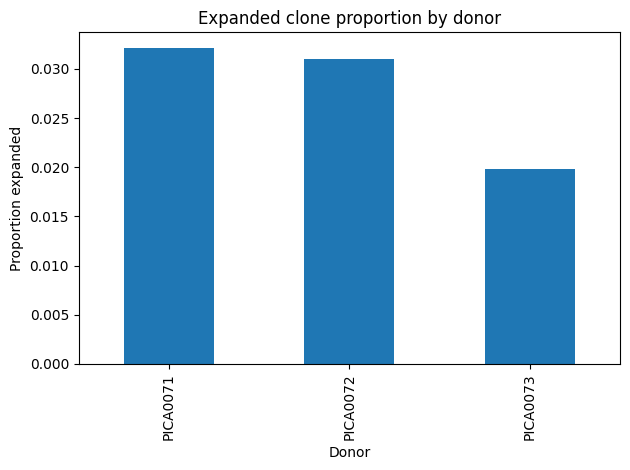

NameError: name 'clone_order' is not defined

In [4]:
# donor-level expanded proportion
donor_summary["prop_expanded"].plot(kind="bar")
plt.ylabel("Proportion expanded")
plt.xlabel("Donor")
plt.title("Expanded clone proportion by donor")
plt.tight_layout()
plt.show()

# donor-level clone size category composition
donor_clone_cat = pd.crosstab(
    adata_tcr.obs["pica_id"],
    adata_tcr.obs["clone_id_size_category"],
    normalize="index"
).reindex(columns=clone_order, fill_value=0)

donor_clone_cat.plot(kind="bar", stacked=True)
plt.ylabel("Proportion")
plt.xlabel("Donor")
plt.title("Clone size categories by donor")
plt.legend(title="Clone size", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


/scratch/temp/22775081/ipykernel_2415511/2992013550.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


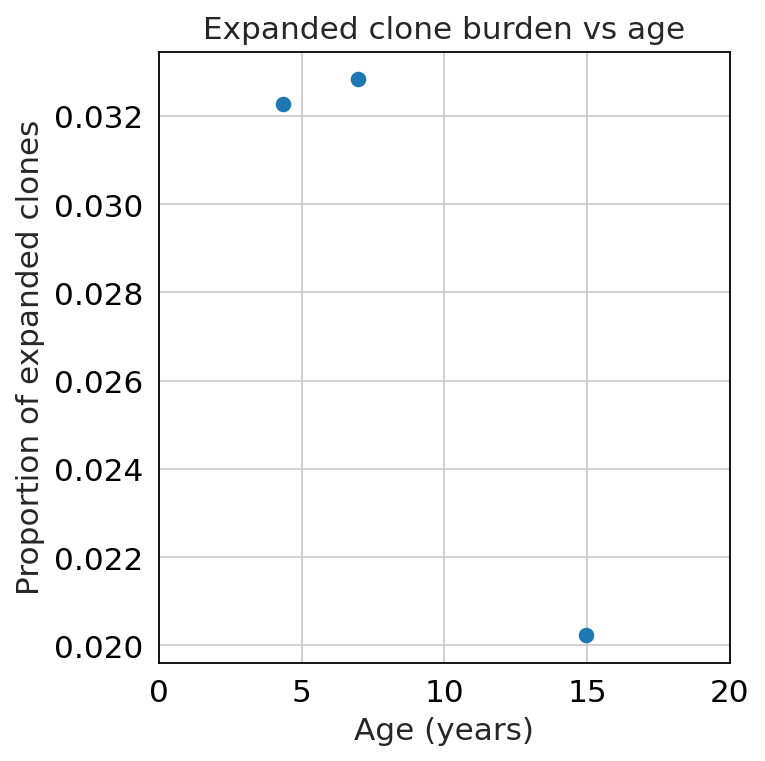

In [ ]:
# continuous age
donor_expansion = (
    adata_tcr.obs.groupby(donor_col)
    .agg(
        Age_years=("Age_years", "first"),
        prop_expanded=("expanded_clone", "mean")
    )
    .dropna()
    .sort_values("Age_years")
)

plt.scatter(donor_expansion["Age_years"], donor_expansion["prop_expanded"])

for donor, row in donor_expansion.iterrows():
    plt.text(row["Age_years"], row["prop_expanded"], str(donor), fontsize=8)

plt.xlim(0, max(20, donor_expansion["Age_years"].max() + 2))
plt.xlabel("Age (years)")
plt.ylabel("Proportion of expanded clones")
plt.title("Expanded clone burden vs age")
plt.tight_layout()
plt.show()

/scratch/temp/22775081/ipykernel_2415511/880391604.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


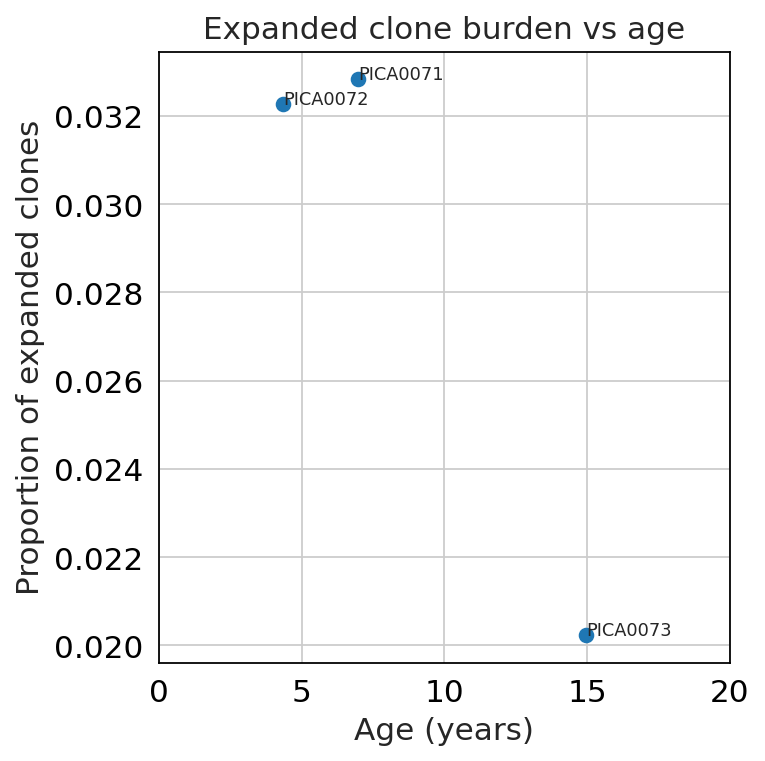

In [130]:
donor_expansion = (
    adata_tcr.obs.groupby("pica_id")
    .agg(
        Age_years=("Age_years", "first"),
        prop_expanded=("expanded_clone", "mean")
    )
    .dropna()
    .sort_values("Age_years")
)

plt.scatter(donor_expansion["Age_years"], donor_expansion["prop_expanded"])

for donor, row in donor_expansion.iterrows():
    plt.text(row["Age_years"], row["prop_expanded"], str(donor), fontsize=8)

plt.xlim(0, 20)
plt.xlabel("Age (years)")
plt.ylabel("Proportion of expanded clones")
plt.title("Expanded clone burden vs age")
plt.tight_layout()
plt.show()

In [ ]:
adata_cd4.write("/scratch/user/s4575250/BIOX7014_Thesis/write/04_TCR/PICA_pool1_cd4_tcr_annotated.h5ad")


In [2]:
adata_tcr = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/04_TCR/PICA_pool1_cd4_tcr_annotated.h5ad")

## comptational estimation
- Shannon diversity
- Simpson diversity
- Inverse diversity
- Clonality
- Richness

In [5]:
# compute clone counts per donor
clone_sizes = (
    adata_tcr.obs
    .groupby(["pica_id", "clone_id"])
    .size()
    .reset_index(name="clone_count")
)
clone_sizes

/scratch/temp/23581889/ipykernel_3069228/2774797296.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,pica_id,clone_id,clone_count
0,PICA0071,No_contig,82
1,PICA0071,sample0_clonotype32,0
2,PICA0071,sample0_clonotype40,5
3,PICA0071,sample0_clonotype42,0
4,PICA0071,sample0_clonotype46,4
...,...,...,...
40114,PICA0073,sample0_clonotype26902,0
40115,PICA0073,sample0_clonotype26904,0
40116,PICA0073,sample0_clonotype26909,1
40117,PICA0073,sample0_clonotype26913,0


In [6]:
def compute_metrics(df):
    counts = df["clone_count"].values
    freq = counts / counts.sum()

    shannon = entropy(freq)
    simpson = 1 - np.sum(freq**2)
    richness = len(counts)

    clonality = 1 - (shannon / np.log(richness)) if richness > 1 else 0

    return pd.Series({
        "Shannon": shannon,
        "Simpson": simpson,
        "Richness": richness,
        "Clonality": clonality
    })

diversity = clone_sizes.groupby("pica_id").apply(compute_metrics)

/scratch/temp/23581889/ipykernel_3069228/2405576008.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/temp/23581889/ipykernel_3069228/2405576008.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [7]:
donor_summary = donor_summary.join(diversity)
donor_summary

,n_tcr_cells,n_expanded,prop_expanded,median_clone_size,mean_clone_size,Age_years,Sex,Shannon,Simpson,Richness,Clonality
pica_id,,,,,,,,,,,
PICA0071,3798,122,0.032122,1.0,1.054360,6.99,Male,8.117568,0.999262,13373.0,0.145608
PICA0072,5545,172,0.031019,1.0,1.050272,4.36,Male,8.385837,0.998328,13373.0,0.117373
PICA0073,4642,92,0.019819,1.0,1.026403,14.97,Male,8.331326,0.999347,13373.0,0.123110


In [8]:
def size_bin(x):
    if x == 1:
        return "1"
    elif x <= 5:
        return "2–5"
    elif x <= 10:
        return "6–10"
    else:
        return ">10"

clone_sizes["size_bin"] = clone_sizes["clone_count"].apply(size_bin)

clone_dist = (
    clone_sizes
    .groupby(["pica_id", "size_bin"], observed=True)
    .size()
    .rename("n_clones")
    .reset_index()
)

clone_dist["proportion"] = (
    clone_dist["n_clones"] /
    clone_dist.groupby("pica_id")["n_clones"].transform("sum")
)

/scratch/temp/23581889/ipykernel_3069228/2159812861.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


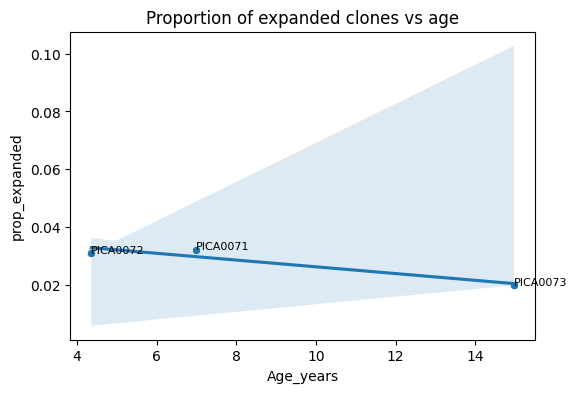

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
sns.regplot(data=donor_summary, x="Age_years", y="prop_expanded", ax=ax, scatter=False)
sns.scatterplot(data=donor_summary, x="Age_years", y="prop_expanded", ax=ax)

for idx, row in donor_summary.reset_index().iterrows():
    ax.text(row["Age_years"], row["prop_expanded"], str(row["pica_id"]), fontsize=8)

ax.set_title("Proportion of expanded clones vs age")
plt.show()

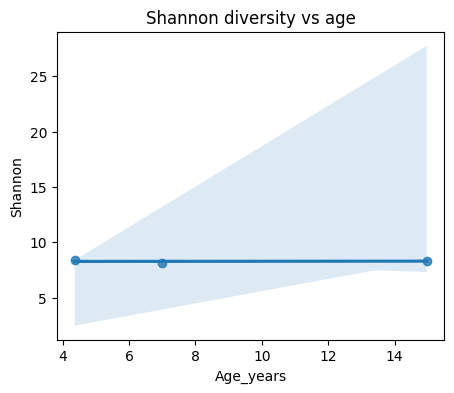

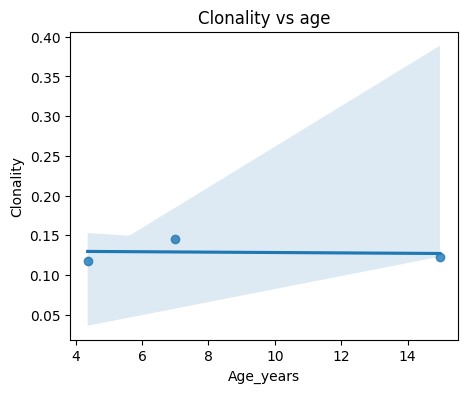

In [10]:
fig, ax = plt.subplots(figsize=(5,4))
sns.regplot(data=donor_summary, x="Age_years", y="Shannon", ax=ax)
ax.set_title("Shannon diversity vs age")
plt.show()

fig, ax = plt.subplots(figsize=(5,4))
sns.regplot(data=donor_summary, x="Age_years", y="Clonality", ax=ax)
ax.set_title("Clonality vs age")
plt.show()

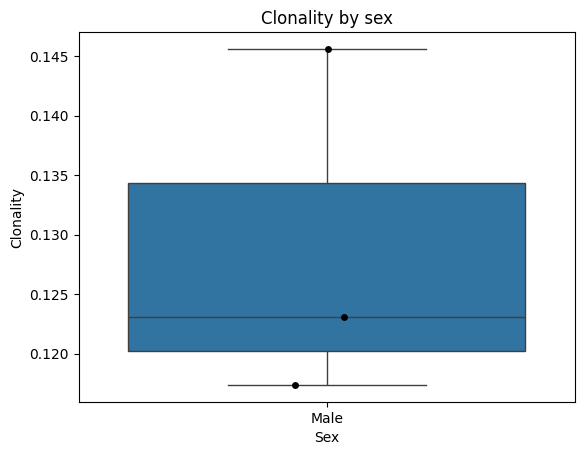

In [11]:
sns.boxplot(data=donor_summary.reset_index(), x="Sex", y="Clonality")
sns.stripplot(data=donor_summary.reset_index(), x="Sex", y="Clonality", color="black")
plt.title("Clonality by sex")
plt.show()

In [13]:
print(pivot_df.columns)

Index(['1', '2–5', '>10'], dtype='object', name='size_bin')


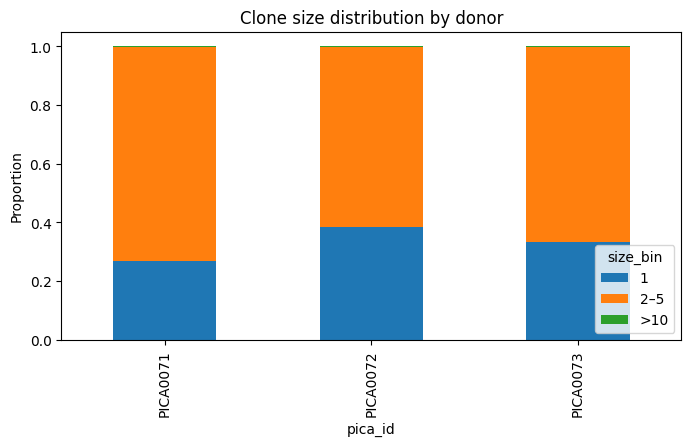

In [14]:
pivot_df = clone_dist.pivot(index="pica_id", columns="size_bin", values="proportion").fillna(0)

pivot_df = pivot_df[["1", "2–5", ">10"]]

pivot_df.plot(kind="bar", stacked=True, figsize=(8,4))
plt.ylabel("Proportion")
plt.title("Clone size distribution by donor")
plt.xticks(rotation=90)
plt.show()

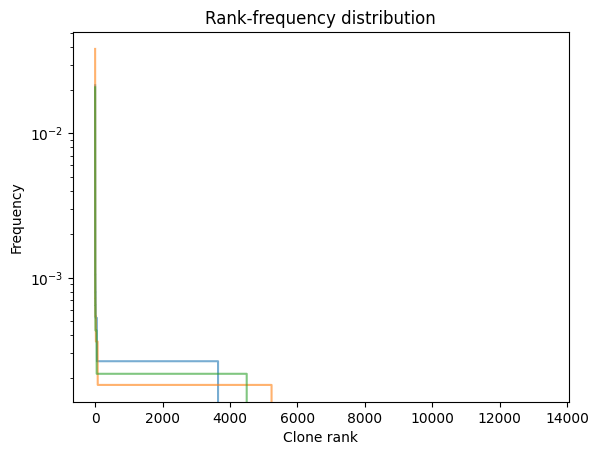

In [17]:
for donor in clone_sizes["pica_id"].unique():
    df = clone_sizes[clone_sizes["pica_id"] == donor]
    freq = np.sort(df["clone_count"].values)[::-1]
    freq = freq / freq.sum()

    plt.plot(freq, alpha=0.6)

plt.yscale("log")
plt.xlabel("Clone rank")
plt.ylabel("Frequency")
plt.title("Rank-frequency distribution")
plt.show()